In [1]:
import pickle
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display

run = pickle.loads(Path(".run.pkl").read_bytes())
card, ev, constants = run["card"], run["evidence"], run["constants"]
gates = {g["number"]: g for g in run["gates"]}
pd.set_option("display.max_colwidth", None)
plt.rcParams.update({"figure.figsize": (9, 3), "axes.spines.top": False, "axes.spines.right": False,
                     "font.size": 9, "axes.titlesize": 10})
INK, GREY, MARK = "#1f4e79", "#a6a6a6", "#c0504d"


def text(value):
    return " ".join(str(value).split()) if value else "—"


def shown(value):
    if value is None:
        return "—"
    if isinstance(value, (list, tuple)):
        return "; ".join(map(str, value)) or "none"
    if isinstance(value, float):
        return float(f"{value:.4g}")
    return value


def table(figures):
    display(pd.Series({k: shown(v) for k, v in figures.items()}, dtype=object).to_frame().T.set_index(pd.Index([""])))


def gate(number):
    g = gates[number]
    reason = g["reason"].removeprefix("not computed: ")
    word = {True: "Passes", False: "Fails", None: "Not computed"}[g["passed"]]
    display(Markdown(f"**{word}**: {reason.rstrip('.')}."))
    if g["figures"]:
        table(g["figures"])


failed = run["failed"]
headline = ("passes gates 1 to 7" if failed is None
            else f"stops at gate {failed}, {gates[failed]['name'].lower()}: {gates[failed]['reason']}")
display(Markdown(f"# {card['id']}\n\nTheory **{card.get('theory', '—')}**. The battery's verdict: "
                 f"the strategy {headline}."))

# CA-014-02-dollar-trend-rotation

Theory **CA-014**. The battery's verdict: the strategy stops at gate 4, multiple testing: DSR 0.367 below 0.9 over 73 effective trials.

## Thesis

In [2]:
prediction = card.get("prediction") or {}
if isinstance(prediction, dict):
    prediction = ", ".join(f"{k}: {v}" for k, v in prediction.items())
display(Markdown(f"**Mechanism.** {text(card.get('mechanism'))}\n\n"
                 f"**Prediction.** {text(prediction)}\n\n"
                 f"**What would refute it.** {text(card.get('refuted_if'))}\n\n"
                 f"**Horizon.** {text(card.get('horizon'))}"))

**Mechanism.** Commodities are quoted in dollars, so the dollar and commodities trend in opposite directions: a falling dollar lifts commodities and gold, which lift inflation expectations and rates, and the inflation-type sectors gain while bonds and the rate-sensitive sectors lag; a rising dollar does the reverse and favours US bonds. The dollar's trend therefore tells which side of the markets leads, through commodities, and the lead persists for months.

**Prediction.** sign: positive, size: an appraisal ratio of about 0.1 to 0.25 over the nine funds held in equal parts, on the new sessions and the whole sample alike, an alpha of about 0.7 to 1.75% a year on a tracking error of about 7% (CA-014-01's published alpha over its appraisal ratio, the same two sides), costs about 0.4 to 0.5% a year; an assumption, since the source reports charts, not statistics, and calls the dollar the hardest market to fit, its effect delayed by months to two years; set after CA-014-01's published results, which it cannot be separated from

**What would refute it.** Judged on the new sessions: those from the first target to 2022-12-31 into which the side the base holds, set by its last target before the session, differs from the side CA-014-01's rule (its base, average 200, legs "all"), rebuilt over the same market, holds into it, or into which that rule holds nothing (up to and including its first holding's session, 2006-11-20), a session's return being earned by the side held into it; the sessions of 2022, whose outcome CA-014-01's published edge for that year mirrors, are left out: 1,563 sessions, about 6.2 years, counted from the signals. On them the base holds what CA-014-01 did not. The figure is the annualised Sharpe ratio of gate 4's daily series (the base's excess returns hedged of the benchmark's with the whole-sample beta) restricted to those sessions, measured to about ±0.40, and the same restricted further to the ordinary monetary regimes, the sessions whose bill rate, as the market's rf gives it (the rate set the session before), is 0.25% a year or more, 829 of them, measured to about ±0.55; both computed by the verdict apart from the battery. The theory is refuted in this form if the first is -0.1 or less and the second zero or less: where the dollar's trend and the commodity/bond ratio's disagree, the side the dollar chose did not lead, outside the zero-rate years too. Any other result short of passing gates 1 to 7 is not proven, not refuted. No placebo rank enters the clause: the placebos shift the whole sample, three fifths of it CA-014-01's published positions. The variant, gold and commodities against the notes, tests the dollar relations alone: the verdict computes, apart from the battery, its excess returns hedged with the whole-sample beta of those of GLD, DBC and IEF held in equal parts, those of the three that trade, reset when it sets targets, at the same costs, and the annualised Sharpe ratio of that series on the same new sessions and on their ordinary regimes. That claim is refuted in this form if the first is -0.1 or less and the second zero or less; any other result leaves it not shown. Reported apart, not graded, with the same figures: the base and the variant over the whole sample from the first target and over its ordinary regimes; over the new sessions of 2022; over the new sessions with 2022 kept; and over the graded sessions without 2008, 2009, 2012, 2014, 2015 and 2016, whose edge CA-014-01's verdict published pooled over each year.

**Horizon.** months

## Data

In [3]:
x = ev.get("excess")
start, end = constants["in sample"]
cannot_run = gates[1]["reason"].startswith("the strategy cannot run")
broke = gates[1]["reason"].startswith("cannot be computed: ")        # the runs every gate judges broke
evaluated = (f"evaluated from the first session the strategy holds an asset, {x.index[0].date()}, to "
             f"{x.index[-1].date()}" if x is not None and len(x)
             else "not evaluated: the strategy cannot run" if cannot_run
             else f"not evaluated: the runs every gate judges broke ({gates[1]['reason'].split(': ', 1)[1]})"
             if broke else "not evaluated: nothing was held")
display(Markdown(
    f"Daily closes adjusted for dividends and splits, snapshot **{run['snapshot']}**. "
    f"Universe: {', '.join(card['universe'])}. In-sample {start} to {end}, {evaluated}; "
    f"holdout {' to '.join(constants['holdout'])}, opened once, at gate 7. "
    f"Returns are above the Treasury-bill rate, net of costs."))

Daily closes adjusted for dividends and splits, snapshot **2026-09-22+2026-09-23**. Universe: XLE, XLB, GLD, DBC, XLP, XLV, XLF, XLU, IEF. In-sample 2005-01-01 to 2022-12-31, evaluated from the first session the strategy holds an asset, 2005-09-27, to 2022-12-30; holdout 2023-01-01 to 2025-12-31, opened once, at gate 7. Returns are above the Treasury-bill rate, net of costs.

## Signal

On every session, the dollar's reading is USDCHF over EURCHF in the market's signal rates, each the close of the last day before the session: the dollar's price in euros, a proxy for the dollar index. Its mean is the mean of the readings that exist among the last average sessions up to and including the session, when at least nine tenths of them exist. The dollar is falling when the reading is below its mean, rising otherwise. On the first session of each week on which the reading and its mean exist, a falling dollar holds the inflation side and a rising one the rate-sensitive side. Under legs "all", the inflation side is XLE, XLB, GLD and DBC, and the rate-sensitive side XLP, XLV, XLF, XLU and IEF; under legs "classes", the inflation side is GLD and DBC, and the rate-sensitive side IEF. The funds of the side held that trade on the session share the portfolio equally; if none trades, the targets are zero on every fund. A week whose first session has no reading or no mean sets no target, and the portfolio holds (EURCHF has no close from 2008-08-01 to 2008-08-25, its close of 31 July read through 7 August, none from 8 to 26 August, so the weeks of 11, 18 and 25 August 2008 set none). The targets start on the first such session, 2005-09-26.

- **average**: readings of the dollar averaged to give its trend, Murphy's 200-day (40-week) average
- **legs**: "all" holds the commodity, gold and note funds with the sectors of each side; "classes" holds gold and commodities against the notes alone

,average,legs
base,200,all
variant 1,200,classes


Parameter neighbours, moved one at a time for gate 6: average at ±25%: 150, 250; average at ±50%: 100, 300.

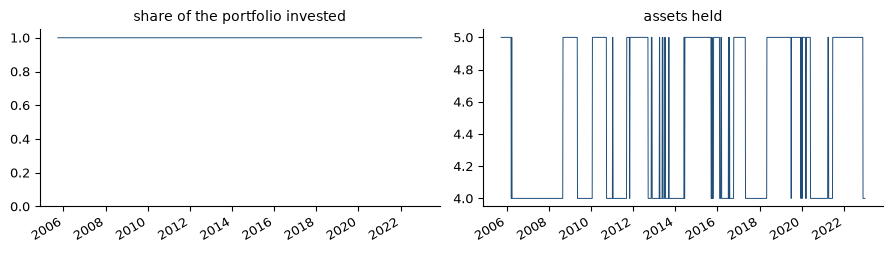

In [4]:
display(Markdown(text(card.get("signal"))))
parameters = card.get("parameters") or {}
if parameters:
    display(Markdown("\n".join(f"- **{k}**: {text(v)}" for k, v in parameters.items())))
variants = pd.DataFrame(card["variants"], index=["base"] + [f"variant {k}" for k in range(1, len(card["variants"]))])
display(variants)
neighbours = card.get("neighbours") or {}
if neighbours:
    display(Markdown("Parameter neighbours, moved one at a time for gate 6: "
                     + "; ".join(f"{p} at ±{step}%: {', '.join(map(str, values))}"
                                 for p, steps in neighbours.items() for step, values in steps.items()) + "."))
if "exposure" in ev:
    fig, (a, b) = plt.subplots(1, 2, figsize=(9, 2.6))
    ev["exposure"].plot(ax=a, color=INK, linewidth=0.7)
    a.set_title("share of the portfolio invested")
    a.set_ylim(0, 1.05)
    ev["assets held"].plot(ax=b, color=INK, linewidth=0.7)
    b.set_title("assets held")
    for axis in (a, b):
        axis.set_xlabel("")
    plt.tight_layout()

## Equity against the benchmark

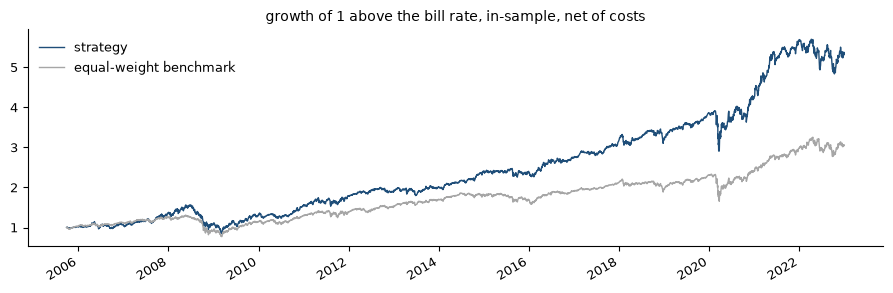

In [5]:
if x is not None and len(x):
    b = ev["benchmark excess"]
    fig, ax = plt.subplots()
    (1 + x).cumprod().plot(ax=ax, color=INK, linewidth=1, label="strategy")
    (1 + b).cumprod().plot(ax=ax, color=GREY, linewidth=1, label="equal-weight benchmark")
    ax.set_title("growth of 1 above the bill rate, in-sample, net of costs")
    ax.set_xlabel("")
    ax.legend(frameon=False)
    plt.tight_layout()
else:
    display(Markdown("The strategy cannot run: there is no equity to draw." if cannot_run
                     else "The runs every gate judges broke: there is no equity to draw." if broke
                     else "Nothing was held in-sample: there is no equity to draw."))

## Gate 1 · Hygiene

Protects against look-ahead, bad data and too little evidence.

**Passes**: no look-ahead on 200 dates, 53 decisions over 17.2 years.

,dates checked,look-ahead breaks,same-day breaks,memory,memory dates checked,memory breaks,data problems,clustered decisions,years in-sample,years needed
,200,0,0,252,100,0,none,53,17.25,5


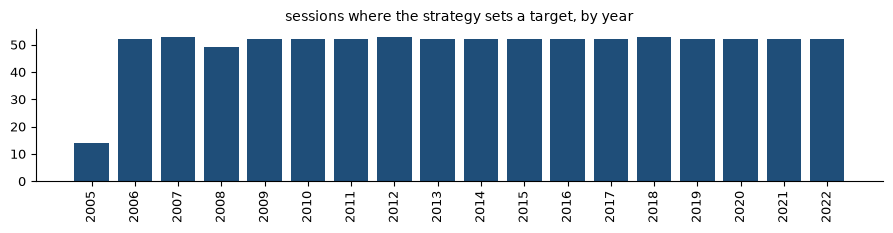

In [6]:
gate(1)
days = ev.get("target days")
if days is not None and len(days):
    per_year = pd.Series(1, index=days).groupby(days.year).sum()
    fig, ax = plt.subplots(figsize=(9, 2.4))
    ax.bar(per_year.index.astype(str), per_year, color=INK)
    breaks = sorted({d.year for variant in ev["timing breaks"].values() for kind in variant.values() for d in kind})
    for year in breaks:
        ax.bar(str(year), per_year.get(year, 0), color=MARK)
    ax.set_title("sessions where the strategy sets a target, by year" + ("; red: a timing break" if breaks else ""))
    ax.tick_params(axis="x", rotation=90)
    plt.tight_layout()

## Gate 2 · Economic edge

Protects against an edge explained by costs or by market exposure.

**Passes**: Sharpe 0.69 against the benchmark's 0.53, alpha 3.48%, 0.67 at twice the costs.

,Sharpe,benchmark Sharpe,alpha,Sharpe at 2x costs,alpha at 2x costs,gross Sharpe,costs a year,costs in Sharpe units
,0.6878,0.5257,0.03476,0.6665,0.03176,0.7092,0.003391,0.02116


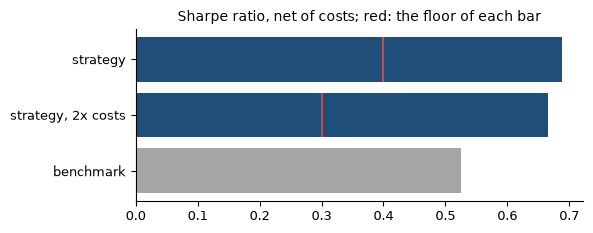

In [7]:
gate(2)
f = gates[2]["figures"]
if f:
    floors = constants["floors"]
    rows = [("benchmark", f["benchmark Sharpe"], GREY, None),
            ("strategy, 2x costs", f["Sharpe at 2x costs"], INK, floors["Sharpe at 2x costs"]),
            ("strategy", f["Sharpe"], INK, floors["Sharpe"])]
    fig, ax = plt.subplots(figsize=(6, 2.4))
    for y, (label, value, colour, floor) in enumerate(rows):
        ax.barh(y, value, color=colour)
        if floor is not None:
            ax.vlines(floor, y - 0.4, y + 0.4, color=MARK, linewidth=1.5)
    ax.set_yticks(range(len(rows)), [r[0] for r in rows])
    ax.set_title("Sharpe ratio, net of costs; red: the floor of each bar")
    plt.tight_layout()

## Gate 3 · Significance

Protects against luck, and against being paid only for being invested. A strategy that holds nearly every asset that trades is close to its benchmark: its placebos differ from it by little, details of the path decide its rank, and gates 2 and 4 judge it.

**Passes**: PSR 0.999, beats 99% of 1000 shifted placebos.

,PSR,placebo sessions,placebos,placebos beaten
,0.9992,4347,1000,0.99


Assets that start trading after 2005-09-26: DBC. A placebo shifts their weights only between days when they trade. Where it draws from a day before their start, it keeps their own weights; where it draws from a day after their start onto a day before it, the share it cannot hold yet takes the strategy's own weights of that day, and with them its timing: skill that lies before a late start is judged against placebos that share it, and is found less often. Where the strategy holds none of the assets shifted that day, the shifted weights take that share instead.

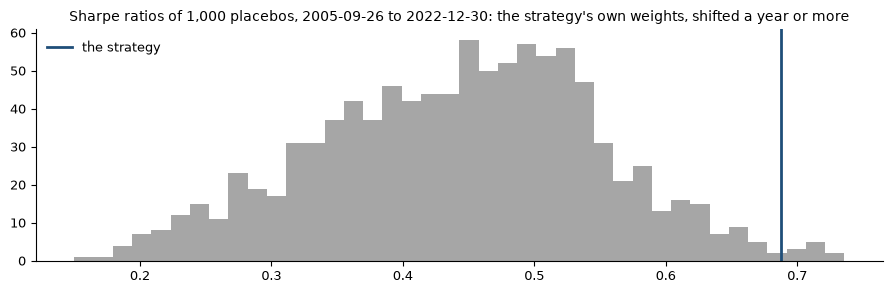

In [8]:
gate(3)
if "placebos" in ev:
    fig, ax = plt.subplots()
    ax.hist(ev["placebos"], bins=40, color=GREY)
    ax.axvline(ev["placebo own Sharpe"], color=INK, linewidth=2, label="the strategy")
    first, last = (d.date() for d in ev["placebo window"])
    ax.set_title(f"Sharpe ratios of {len(ev['placebos']):,} placebos, {first} to {last}: the strategy's own weights, "
                 f"shifted a year or more")
    ax.legend(frameon=False)
    plt.tight_layout()
    if ev.get("placebo late assets"):
        display(Markdown(f"Assets that start trading after {first}: {', '.join(ev['placebo late assets'])}. A placebo "
                         f"shifts their weights only between days when they trade. Where it draws from a day before their "
                         f"start, it keeps their own weights; where it draws from a day after their start onto a day before "
                         f"it, the share it cannot hold yet takes the strategy's own weights of that day, and with them its "
                         f"timing: skill that lies before a late start is judged against placebos that share it, and is "
                         f"found less often. Where the strategy holds none of the assets shifted that day, the shifted "
                         f"weights take that share instead."))

## Gate 4 · Multiple testing

Protects against the best of many tries: the edge, hedged of the benchmark, deflated by every trial the registry holds.

**Fails**: DSR 0.367 below 0.9 over 73 effective trials.

,trials,effective trials,appraisal ratio,Sharpe expected by luck,DSR
,80,73,0.4876,0.6293,0.367


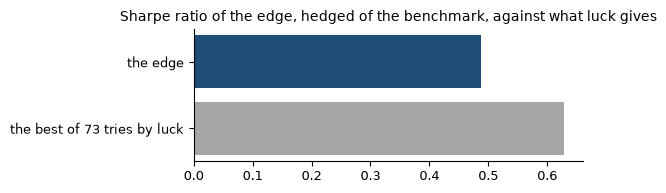

In [9]:
gate(4)
f = gates[4]["figures"]
if f and "appraisal ratio" in f:
    fig, ax = plt.subplots(figsize=(6, 2.0))
    ax.barh([0, 1], [f["Sharpe expected by luck"], f["appraisal ratio"]], color=[GREY, INK])
    tries = f["effective trials"]
    ax.set_yticks([0, 1], [f"the best of {tries} {'try' if tries == 1 else 'tries'} by luck", "the edge"])
    ax.set_title("Sharpe ratio of the edge, hedged of the benchmark, against what luck gives")
    plt.tight_layout()

## Gate 5 · Stability

Protects against an edge that lives in one variant or one episode.

**Fails**: the blend of the variants fails gate 4.

,blend passes gate 2,blend passes gate 3,blend passes gate 4,worst variant Sharpe,positive blocks,best year,alpha without the best year
,True,True,False,0.6025,5,2007,0.03007


The blend of the variants: gate 4, DSR 0.410 below 0.9 over 73 effective trials.

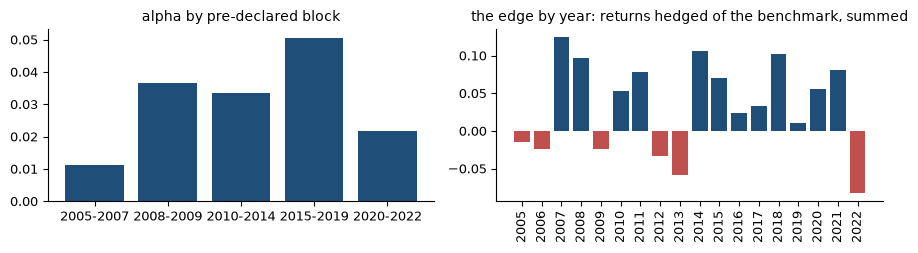

In [10]:
gate(5)
if "blocks" in ev:
    fig, (a, c) = plt.subplots(1, 2, figsize=(9, 2.6))
    blocks = pd.Series({k: (v if v is not None else np.nan) for k, v in ev["blocks"].items()})
    a.bar(blocks.index, blocks.fillna(0), color=[INK if v > 0 else MARK for v in blocks.fillna(0)])
    a.set_title("alpha by pre-declared block")
    a.axhline(0, color="black", linewidth=0.6)
    by_year = ev["edge by year"]
    c.bar(by_year.index.astype(str), by_year, color=[INK if v > 0 else MARK for v in by_year])
    c.set_title("the edge by year: returns hedged of the benchmark, summed")
    c.tick_params(axis="x", rotation=90)
    plt.tight_layout()
failed_blend = {n: reason for n, reason in ev.get("blend", {}).items() if gates[5]["figures"].get(f"blend passes gate {n}") is False}
if failed_blend:
    display(Markdown("The blend of the variants: " + "; ".join(f"gate {n}, {r}" for n, r in failed_blend.items()) + "."))

## Gate 6 · Robustness

Protects against a peak, one asset, timing too tight and a clone.

**Passes**: neighbours, clusters, assets, bitcoin, delay and survivors all hold.

,neighbour median ratio,lowest ±25% ratio,neighbours that hold the base,worst cluster out,worst cluster out ratio,largest P&L share,asset with the largest share,one day late ratio,highest correlation with a survivor,survivor most correlated
,0.9095,0.9351,none,sectors,0.876,0.1782,DBC,0.9603,—,—


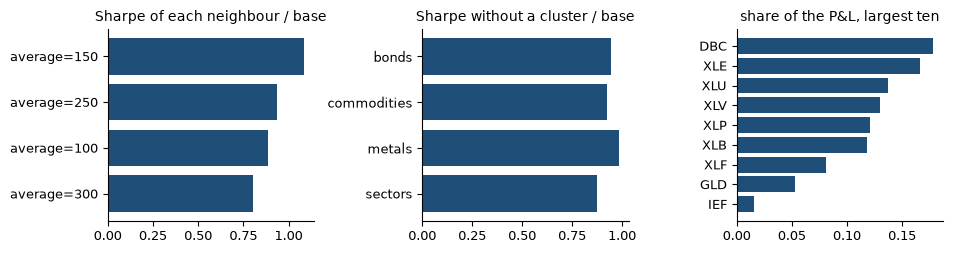

In [11]:
gate(6)
panels = [(k, ev.get(k)) for k in ("neighbours", "clusters out", "P&L shares") if ev.get(k) is not None and len(ev.get(k))]
if panels:
    fig, axes = plt.subplots(1, len(panels), figsize=(3.2 * len(panels), 2.6))
    for axis, (name, values) in zip(np.atleast_1d(axes), panels):
        values = pd.Series(values).head(10)
        axis.barh(values.index.astype(str), values, color=INK)
        axis.set_title({"neighbours": "Sharpe of each neighbour / base", "clusters out": "Sharpe without a cluster / base",
                        "P&L shares": "share of the P&L, largest ten"}[name])
        axis.invert_yaxis()
    plt.tight_layout()
if ev.get("without bitcoin"):
    display(Markdown("Without bitcoin, gate 2's figures:"))
    table(ev["without bitcoin"])

## Gate 7 · Sealed holdout

Protects against bugs and large decay, on years kept aside and opened once.

**Passes**: holdout Sharpe 0.46 and alpha -0.67%, both above the in-sample 10th percentile.

,holdout Sharpe,Sharpe floor,holdout alpha,alpha floor,variants rewritten,dates checked,look-ahead breaks,same-day breaks,data problems
,0.458,-0.007345,-0.006655,-0.0253,0,40,0,0,none


Red: the 10th percentile of the in-sample paths, the floor; blue: the holdout.

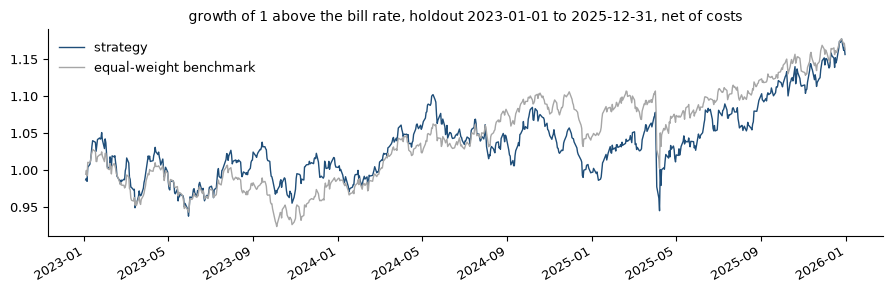

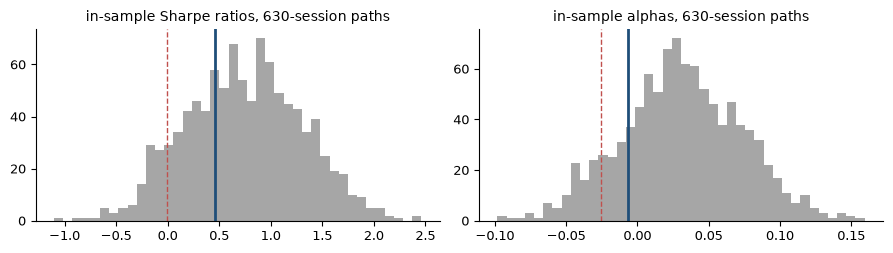

In [12]:
gate(7)
f = gates[7]["figures"]
if "holdout excess" in ev and len(ev["holdout excess"]):
    fig, ax = plt.subplots()
    (1 + ev["holdout excess"]).cumprod().plot(ax=ax, color=INK, linewidth=1, label="strategy")
    (1 + ev["holdout benchmark excess"]).cumprod().plot(ax=ax, color=GREY, linewidth=1, label="equal-weight benchmark")
    ax.set_title(f"growth of 1 above the bill rate, holdout {' to '.join(constants['holdout'])}, net of costs")
    ax.set_xlabel("")
    ax.legend(frameon=False)
    plt.tight_layout()
if "bootstrap" in ev and f:
    pct = constants["percentile"]
    fig, (a, c) = plt.subplots(1, 2, figsize=(9, 2.6))
    for axis, key, mark, label in ((a, "Sharpe", "holdout Sharpe", "Sharpe ratio"), (c, "alpha", "holdout alpha", "alpha")):
        axis.hist(ev["bootstrap"][key], bins=40, color=GREY)
        axis.axvline(np.percentile(ev["bootstrap"][key], pct), color=MARK, linestyle="--", linewidth=1)
        axis.axvline(f[mark], color=INK, linewidth=2)
        axis.set_title(f"in-sample {label}s, {constants['window']}-session paths")
    plt.tight_layout()
    display(Markdown(f"Red: the {pct}th percentile of the in-sample paths, the floor; blue: the holdout."))

## Verdict

In [13]:
table = pd.DataFrame([{"gate": f"{g['number']} · {g['name']}",
                       "result": {True: "passes", False: "fails", None: "not computed"}[g["passed"]],
                       "reason": g["reason"].removeprefix("not computed: ")} for g in run["gates"]]).set_index("gate")
display(table)
display(Markdown(f"Thresholds, version {run['thresholds']}. What the verdict means for the theory, and what was "
                 f"learned, is written in [verdict.md](verdict.md)."))

,result,reason
gate,,
1 · Hygiene,passes,"no look-ahead on 200 dates, 53 decisions over 17.2 years"
2 · Economic edge,passes,"Sharpe 0.69 against the benchmark's 0.53, alpha 3.48%, 0.67 at twice the costs"
3 · Significance,passes,"PSR 0.999, beats 99% of 1000 shifted placebos"
4 · Multiple testing,fails,DSR 0.367 below 0.9 over 73 effective trials
5 · Stability,fails,the blend of the variants fails gate 4
6 · Robustness,passes,"neighbours, clusters, assets, bitcoin, delay and survivors all hold"
7 · Sealed holdout,passes,"holdout Sharpe 0.46 and alpha -0.67%, both above the in-sample 10th percentile"


Thresholds, version 4. What the verdict means for the theory, and what was learned, is written in [verdict.md](verdict.md).